In [50]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
import numpy as np
import matplotlib.pyplot as plt
from cns.data_utils import load_samples_out, img_path

In [73]:
plt.rcParams.update({'font.size': 12, 'figure.figsize': (6, 6), 'figure.dpi': 100})	

In [74]:
full = {
    "PCAWG" : load_samples_out("PCAWG_samples.tsv"),
    "TCGA_hg19": load_samples_out("TCGA_hg19_samples.tsv"),
    "TRACERx": load_samples_out("TRACERx_samples.tsv"),
}
gaps = {
    "PCAWG" : load_samples_out("PCAWG_samples_gaps.tsv"),
    "TCGA_hg19": load_samples_out("TCGA_hg19_samples_gaps.tsv"),
    "TRACERx": load_samples_out("TRACERx_samples_gaps.tsv"),	
}
colors = {"PCAWG": "C0", "TCGA_hg19": "C1", "TRACERx": "C2", "combined": "gray"}


Text(0.5, 0, 'Samples with missing portion of genome')

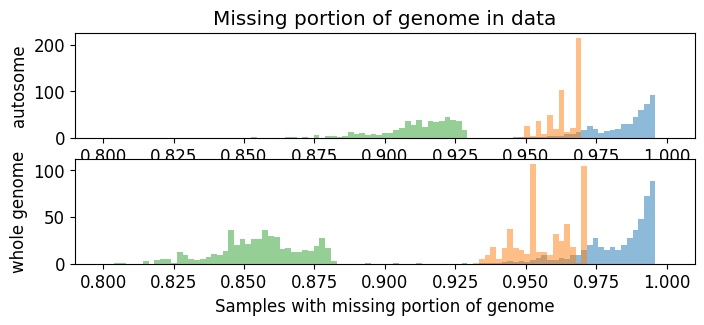

In [75]:
fig, axs = plt.subplots(2, figsize=(8, 3))
bins = np.linspace(.80, 1, 100)
yaxes = ["autosome", "whole genome"]
features = ["cover_het_aut", "cover_het_all"]
for j in range(2):
    for i, (k, v) in enumerate(full.items()):
        axs[j].hist(full[k][features[j]], density=True, bins=bins, alpha=0.5, color=colors[k], label=k)
    axs[j].set_ylabel(yaxes[j])
axs[0].set_title("Missing portion of genome in data")
axs[1].set_xlabel("Samples with missing portion of genome")
plt.savefig(f"{img_path}/coverage_all_vs_aut.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{img_path}/coverage_all_vs_aut.pdf", bbox_inches="tight")

PCAWG whole genome 0.9847373731681054
TCGA_hg19 whole genome 0.9638500799305667
TRACERx whole genome 0.9118084721485119
PCAWG filtered 0.9992937160542891
TCGA_hg19 filtered 0.9994988817913454
TRACERx filtered 0.9960110372290752


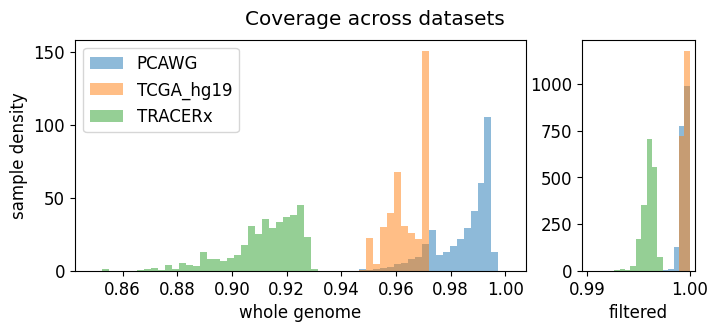

In [109]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), gridspec_kw={'width_ratios': [4, 1]})
bins = [np.linspace(.85, 1, 60), np.linspace(.99, 1, 20)]
xaxes = ["whole genome", "filtered"]
source = [full, gaps]
for j in range(2):
    for i, (k, v) in enumerate(full.items()):
        axs[j].hist(source[j][k]["cover_het_aut"], density=True, bins=bins[j], alpha=0.5, color=colors[k], label=k)
        print(k, xaxes[j], np.mean(source[j][k]["cover_het_aut"].mean()))
    axs[j].set_xlabel(xaxes[j])
axs[0].legend()
axs[0].set_ylabel("sample density")
plt.suptitle("Coverage across datasets")
plt.savefig(f"{img_path}/coverage_whole_vs_gap.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{img_path}/coverage_whole_vs_gap.pdf", bbox_inches="tight")

In [116]:
sum(full["PCAWG"]["cover_het_aut"] < 0.85)

1